In [ ]:
!pip uninstall -y torch torchtext torchvision torchaudio && pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121
!pip install torchtext --no-cache-dir
!pip install einops -q

Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 97.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 87.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 58.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 45.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 101.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/

In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [ ]:
import torch
import torch.nn as nn

In [ ]:
data_set = torch.load("/content/drive/MyDrive/Group Project 2025-2026/training_data.pt")

#Test Data

In [ ]:
img_test1 = data_set['images'][0]
print(img_test1)
img_test1 = img_test1.unsqueeze(0)
print(img_test1.shape)


tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])
torch.Size([1, 1, 64, 128])


In [ ]:
img_test =  torch.randint(0, 2, (4,1 ,50, 200))
img_test = img_test.float()

In [ ]:
print(img_test)

tensor([[[[0., 1., 1.,  ..., 1., 1., 1.],
          [1., 0., 1.,  ..., 0., 1., 0.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 1.],
          [1., 1., 1.,  ..., 0., 1., 1.],
          [0., 0., 1.,  ..., 0., 0., 1.]]],


        [[[0., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 1.,  ..., 0., 0., 1.],
          [1., 1., 1.,  ..., 0., 0., 1.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 1., 0.,  ..., 0., 1., 1.],
          [0., 1., 1.,  ..., 1., 0., 0.]]],


        [[[1., 1., 1.,  ..., 1., 0., 1.],
          [0., 0., 0.,  ..., 1., 1., 1.],
          [0., 1., 1.,  ..., 1., 0., 1.],
          ...,
          [1., 1., 0.,  ..., 1., 0., 1.],
          [1., 0., 1.,  ..., 1., 0., 1.],
          [0., 0., 1.,  ..., 1., 0., 0.]]],


        [[[1., 1., 0.,  ..., 0., 1., 0.],
          [1., 1., 0.,  ..., 1., 1., 1.],
          [0., 1., 0.,  ..., 0., 1., 0.],
          ...,
          [0., 0., 0.,  ..., 1., 1., 0.],
    

In [ ]:
patch_size = 10
number_patch = (img_test.shape[2]*img_test.shape[3])//(patch_size**2)
print(number_patch)

100


In [ ]:
def extract_patches(image, patch_size):
  B, C, H, W = image.shape # Batch, Channel, Height, Width
  assert H % patch_size == 0
  assert W % patch_size == 0
  patchs = image.unfold (2,patch_size,patch_size).unfold(3,patch_size,patch_size)
  patchs = patchs.contiguous().view(B, C, -1, patch_size, patch_size)
  B_new, C_new, N, first_patch_size, second_patch_size = patchs.shape
  patchs = patchs.view(B_new ,N , -1)
  return patchs

In [ ]:
out = extract_patches(img_test,patch_size=patch_size)
print(out.shape)
print(out)

torch.Size([4, 100, 100])
tensor([[[0., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 0.,  ..., 1., 0., 1.],
         [0., 1., 0.,  ..., 0., 1., 0.],
         ...,
         [0., 1., 1.,  ..., 0., 1., 1.],
         [0., 1., 0.,  ..., 0., 0., 1.],
         [1., 0., 1.,  ..., 0., 0., 1.]],

        [[0., 0., 1.,  ..., 1., 0., 1.],
         [1., 0., 1.,  ..., 0., 1., 1.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 1.,  ..., 1., 0., 1.],
         [0., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 0.,  ..., 1., 0., 0.]],

        [[1., 1., 1.,  ..., 0., 1., 0.],
         [1., 0., 0.,  ..., 0., 1., 0.],
         [0., 1., 0.,  ..., 0., 1., 0.],
         ...,
         [0., 0., 1.,  ..., 0., 0., 1.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 1., 0., 0.]],

        [[1., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 1., 1., 0.],
         ...,
         [1., 1., 1.,  ..., 0., 1., 0.],
         [

In [ ]:
class Patch_embedding(nn.Module):
  def  __init__(self,patch_size, num_patchs, embedding_dim):
     super().__init__()
     self.patch_size = patch_size
     self.num_patches = num_patchs
     self.embedding_dim = embedding_dim
     self.patch_embed = nn.Linear(self.patch_size**2,self.embedding_dim)
     self.cls_token = nn.Parameter(torch.randn(1, 1, self.embedding_dim))
     self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, self.embedding_dim))
  def forward(self,x):
    B, N , P = x.shape
    patch_embedding = self.patch_embed(x)
    cls_tokens = self.cls_token.expand(B, -1, -1)
    tokens = torch.cat((cls_tokens, patch_embedding), dim=1)
    return tokens + self.pos_embed


In [ ]:
embed = Patch_embedding(patch_size=10,num_patchs=100,embedding_dim=128)
embedding_output = embed(out)
print(embedding_output.shape)
print(embedding_output)

torch.Size([4, 101, 128])
tensor([[[-4.6141e-01, -6.9559e-02,  1.0847e+00,  ...,  6.5135e-01,
           2.7292e-01,  1.7990e-01],
         [-2.1519e+00, -1.0882e+00, -4.7727e-01,  ..., -1.8733e+00,
          -1.0930e+00,  3.7407e-02],
         [ 8.0482e-02,  1.0227e+00,  1.8726e-01,  ...,  7.8355e-01,
           1.1866e+00,  3.2728e-01],
         ...,
         [-2.2992e-01, -5.0190e-01,  1.0016e-01,  ...,  5.8801e-01,
           1.4225e-01,  1.4902e+00],
         [-1.4749e+00,  8.6365e-01, -8.7046e-02,  ..., -1.3892e+00,
          -8.0522e-01, -3.5651e-01],
         [ 8.5728e-02, -2.0378e-01,  1.4954e+00,  ..., -2.2996e+00,
          -2.0517e-01,  1.9519e+00]],

        [[-4.6141e-01, -6.9559e-02,  1.0847e+00,  ...,  6.5135e-01,
           2.7292e-01,  1.7990e-01],
         [-1.7451e+00, -1.4631e+00,  8.6979e-04,  ..., -1.2773e+00,
          -9.8463e-01,  2.0431e-01],
         [ 5.4828e-01,  6.2463e-01,  8.5078e-01,  ...,  3.0386e-01,
           1.4618e+00, -1.2596e-01],
         ...,

In [ ]:
class MultiheadAttention(nn.Module):
  def __init__(self, embedding_dim, num_head:int=16 , dropout: float = 0) -> None:
     super().__init__()
     self.layer_norm=nn.LayerNorm(embedding_dim)
     self.mha = nn.MultiheadAttention(embed_dim=embedding_dim,
                                      num_heads=num_head,
                                      dropout=dropout,
                                      batch_first=True)
  def forward(self,x):
    x_norm = self.layer_norm(x)
    x_attention,_ = self.mha(query = x_norm,
                           key = x_norm,
                           value = x_norm,
                           need_weights = False)
    return  x + x_attention

In [ ]:
B,N,D = embedding_output.shape
attention_block = MultiheadAttention(embedding_dim = D)
attn_output = attention_block(embedding_output)
print(attn_output.shape)
print(attn_output)

torch.Size([4, 101, 128])
tensor([[[-0.4837, -0.2405,  0.9815,  ...,  0.6661,  0.3677,  0.0701],
         [-2.1547, -1.1959, -0.5800,  ..., -1.8576, -0.9590, -0.1013],
         [ 0.0695,  0.8029,  0.1025,  ...,  0.8307,  1.2554,  0.1881],
         ...,
         [-0.2111, -0.6868,  0.0051,  ...,  0.6265,  0.1986,  1.4366],
         [-1.4748,  0.7041, -0.1742,  ..., -1.3062, -0.7322, -0.4643],
         [ 0.0932, -0.3980,  1.3845,  ..., -2.2635, -0.0707,  1.8525]],

        [[-0.4510, -0.2212,  1.0017,  ...,  0.6399,  0.3655,  0.0710],
         [-1.7101, -1.5560, -0.0809,  ..., -1.2875, -0.8688,  0.0630],
         [ 0.5783,  0.4021,  0.7917,  ...,  0.3372,  1.5181, -0.2413],
         ...,
         [-0.3400, -0.3575,  0.4757,  ...,  0.4460,  0.3842,  1.2973],
         [-1.4634,  0.4732, -0.3086,  ..., -1.2316, -0.5780, -0.9948],
         [ 0.0137, -0.1261,  0.5574,  ..., -2.0351,  0.0340,  2.8382]],

        [[-0.4473, -0.2284,  1.0091,  ...,  0.6834,  0.3424,  0.0789],
         [-1.8801, 

In [ ]:
class MLP_Block(nn.Module):
  def __init__(self, embedding_dim,mlp_size: int = 4096 ,dropout: float = 0.1) :
     super().__init__()
     self.layer_norm=nn.LayerNorm(embedding_dim)
     self.mlp = nn.Sequential(nn.Linear(embedding_dim,mlp_size),
                              nn.GELU(),
                              nn.Dropout(dropout),
                              nn.Linear(mlp_size,embedding_dim),
                              nn.Dropout(dropout))
  def forward(self,x):
    x_norm = self.layer_norm(x)
    x_mlp = self.mlp(x_norm)
    return x + x_mlp

In [ ]:
mlpblock = MLP_Block(attn_output.shape[2])
mlp_output = mlpblock(attn_output)
print(mlp_output.shape)
print(mlp_output)

torch.Size([4, 101, 128])
tensor([[[-2.1480e-01, -3.0176e-01,  2.3699e-01,  ...,  8.3422e-01,
           2.6365e-01,  7.0120e-02],
         [-2.3148e+00, -7.6820e-01, -9.2223e-01,  ..., -1.8362e+00,
          -1.4653e+00, -1.6601e-03],
         [-1.8269e-01,  7.8246e-01,  3.3204e-01,  ...,  7.9828e-01,
           1.1910e+00,  1.8811e-01],
         ...,
         [-3.4477e-01, -8.3360e-01,  3.7741e-01,  ...,  6.2648e-01,
           4.2785e-01,  1.4557e+00],
         [-1.3612e+00,  9.0288e-01,  1.5986e-01,  ..., -1.2871e+00,
          -8.2607e-01, -6.4677e-01],
         [-5.2327e-02, -3.2289e-01,  1.4289e+00,  ..., -1.9529e+00,
          -2.1958e-02,  1.6874e+00]],

        [[-2.8457e-01, -3.1202e-01,  2.9362e-01,  ...,  6.3993e-01,
           2.5540e-01,  7.0983e-02],
         [-1.8653e+00, -1.0935e+00, -5.5365e-01,  ..., -1.2875e+00,
          -8.6879e-01, -1.4734e-02],
         [ 2.1577e-01,  4.2830e-01,  1.1111e+00,  ...,  3.1613e-01,
           1.4640e+00, -4.8531e-01],
         ...,

In [ ]:
class TransformerEncoderLayer(nn.Module):
  def __init__(self, embedding_dim, num_head:int=16 , attn_dropout: float = 0 , mlp_size: int =4096 , mlp_dropout: float = 0.1 ):
     super().__init__()
     self.attn = MultiheadAttention(embedding_dim,num_head,attn_dropout)
     self.mlp = MLP_Block(embedding_dim,mlp_size,mlp_dropout)
  def forward(self,x):
    x_attn = self.attn(x)
    x_mlp = self.mlp(x_attn)
    return x_mlp


In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self, embedding_dim, num_layers, num_head=16, attn_dropout=0, mlp_size=4096, mlp_dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(
                embedding_dim=embedding_dim,
                num_head=num_head,
                mlp_size=mlp_size,
                attn_dropout=attn_dropout,
                mlp_dropout=mlp_dropout
            )
            for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [ ]:
class ViT(nn.Module):
  def __init__(self, patch_size , num_patchs, embedding_dim,num_layer ):
     super().__init__()
     self.patch_size = patch_size
     self.embed = Patch_embedding(patch_size,num_patchs,embedding_dim)
     self.transfor = TransformerEncoder(embedding_dim ,num_layer)
  def forward(self,x):
    out1 = extract_patches(x,self.patch_size)
    out2 = self.embed(out1)
    out3 = self.transfor(out2)
    return out3


In [ ]:
vit = ViT(10,100,128,24)
dinal = vit(img_test)
print(dinal.shape)
print(dinal)

torch.Size([4, 101, 128])
tensor([[[-3.2280,  1.6231, -0.3999,  ...,  0.5754, -0.1214, -1.9709],
         [-3.7524,  2.5946,  0.4039,  ...,  0.5069, -2.8552,  0.2289],
         [-3.3469,  2.7428,  1.6561,  ..., -1.0787, -1.8911,  2.2057],
         ...,
         [-2.1620,  3.1027,  2.3011,  ..., -1.6297, -0.5689, -0.3948],
         [-1.5892,  1.7478,  0.6941,  ..., -1.1216,  1.5260, -0.0458],
         [-1.6251,  1.5689, -1.4356,  ..., -3.1811,  0.6749, -0.1419]],

        [[-3.3992,  2.6646, -1.2485,  ..., -0.5471, -0.1937, -0.9583],
         [-2.3732,  2.3438, -0.7769,  ..., -0.1988, -0.9101,  0.8373],
         [-2.3954,  2.8330, -0.1362,  ..., -2.2063, -1.5412,  1.1340],
         ...,
         [-1.7908,  3.4538,  0.9319,  ..., -0.9776, -1.4030,  0.1383],
         [-1.5173,  2.4816,  0.1240,  ..., -1.0982,  0.6605, -0.1069],
         [-1.8374,  3.3812, -1.7500,  ..., -2.5436,  0.4863,  1.0188]],

        [[-4.2736,  2.3810, -1.9242,  ...,  0.3526, -0.4306, -1.4163],
         [-2.5796, 

In [ ]:
layer = TransformerEncoder(128,24)
out_layer = layer(embedding_output)
print(out_layer.shape)
print(out_layer)

torch.Size([4, 101, 128])
tensor([[[-0.1199, -0.8784,  1.7420,  ..., -0.5704,  2.2029,  2.4713],
         [-1.1185, -2.1109, -0.7924,  ..., -3.9263, -2.6059,  0.4851],
         [ 1.1016,  0.1953,  1.8166,  ..., -1.5530,  1.7748,  1.4129],
         ...,
         [ 0.5895, -1.5864, -1.5790,  ..., -0.5309,  0.1083,  0.4956],
         [-2.7058, -1.3827,  0.8191,  ..., -1.3265, -1.9310,  2.2205],
         [-0.2436, -0.9175,  1.0661,  ..., -4.4553,  0.8383,  2.9264]],

        [[-0.3728, -0.3628,  1.2140,  ..., -0.5897,  2.9650,  2.7732],
         [-1.9447, -3.3809, -0.1983,  ..., -1.8037, -2.3510,  0.2222],
         [ 1.8869, -1.2276,  1.4882,  ..., -1.5857,  3.2034, -0.0305],
         ...,
         [-0.1206, -2.4715, -1.0590,  ..., -0.2300,  0.5839,  2.3701],
         [-1.9002, -1.3991,  1.0654,  ..., -1.5344, -2.1714,  1.1525],
         [ 0.7108, -0.3715,  0.0181,  ..., -2.9059,  1.2286,  3.1893]],

        [[ 0.4565, -0.9317,  1.3942,  ..., -0.4762,  2.9859,  0.3709],
         [-3.2692, 

##############

In [ ]:
def extract_patches1(image, patch_size):
  B, C, H, W = image.shape # Batch, Channel, Height, Width
  assert H % patch_size == 0
  assert W % patch_size == 0
  patchs = image.unfold (2,patch_size,patch_size).unfold(3,patch_size,patch_size)
  patchs = patchs.contiguous().view(B, C, -1, patch_size, patch_size)
  # B_new, C_new, N, first_patch_size, second_patch_size = patchs.shape
  # patchs = patchs.view(B_new ,N , -1)
  return patchs

In [ ]:
out2 = extract_patches1(img_test1,patch_size)

In [ ]:
print(out2)

tensor([[[[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
           [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
           [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
           ...,
           [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
           [ 1.0000,  1.0000,  0.9765,  ...,  1.0000,  1.0000,  1.0000],
           [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000]],

          [[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
           [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
           [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
           ...,
           [ 1.0000,  1.0000,  1.0000,  ...,  0.8667,  0.9059,  0.9765],
           [ 1.0000,  1.0000,  1.0000,  ..., -0.8196, -0.8353,  0.5059],
           [ 1.0000,  1.0000,  1.0000,  ...,  0.7412, -0.4196,  0.2078]],

          [[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
           [ 1.

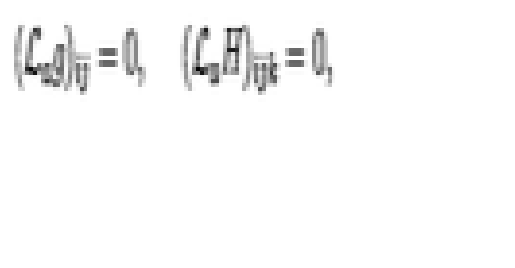

In [ ]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import numpy as np
import matplotlib.pyplot as plt
import torch
img_test2 = data_set['images'][1]
img_tensor = img_test2.cpu()

# Nếu là (H, W) hoặc (1, H, W) → đảm bảo về (H, W)
if img_tensor.ndim == 3:
    img_tensor = img_tensor.squeeze(0)

# Nếu giá trị không nằm [0, 1], chuẩn hóa về 0–1
if img_tensor.min() < 0 or img_tensor.max() > 1:
    img_tensor = (img_tensor - img_tensor.min()) / (img_tensor.max() - img_tensor.min())

plt.imshow(img_tensor, cmap="gray")
plt.axis("off")
plt.show()


In [ ]:
out2 = out2.squeeze(0)
print(out2.shape)

torch.Size([32, 16, 16])


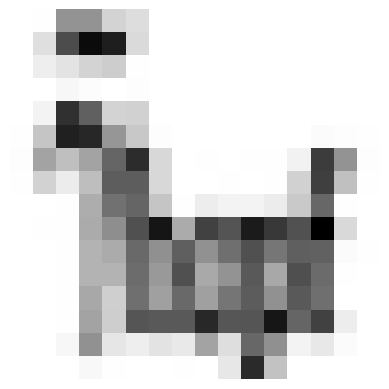

In [ ]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import numpy as np
import matplotlib.pyplot as plt
import torch
img_test2 = out2[8]
img_tensor = img_test2.cpu()

# Nếu là (H, W) hoặc (1, H, W) → đảm bảo về (H, W)
if img_tensor.ndim == 3:
    img_tensor = img_tensor.squeeze(0)

# Nếu giá trị không nằm [0, 1], chuẩn hóa về 0–1
if img_tensor.min() < 0 or img_tensor.max() > 1:
    img_tensor = (img_tensor - img_tensor.min()) / (img_tensor.max() - img_tensor.min())

plt.imshow(img_tensor, cmap="gray")
plt.axis("off")
plt.show()
